# Bessel–Gauss beam radial profile

This notebook explores two aspects of the axicon-based implementation of a Gauss-Bessel beam in Rao (2024):

1. How intensity $I_\ell^{BG}(r,z)$ changes along propagation z.
2. How radial rings given by $J_\ell^{2}(k_r, r)$ look at different z slices (fix a value for z).

Rao (Eq. 3.17) gives the axicon-generated Bessel beam intensity distribution as approximately proportional to:
$$
I_\ell^{BG}(r,z) \propto
\left(\frac{z}{z_{\max}^{G}}\right)^{2\ell+1}
\exp\left(-\frac{2z^2}{(z_{\max}^{G})^2}\right)
J_\ell^2(k_r r)
$$
with the range of the Bessel beam formed by a Gaussian beam source propagating through an axicon lens given by (Eq 3.18):
$$
z_{\max}^{G} = \frac{k w}{k_r}
\approx \frac{w}{(n-1)\alpha}
$$

* $w$ - Gaussian spot size of the axicon
* $n$ - axicon refractive index~=1.457 for UV fused silica at 650-698nm
* $\alpha$ - axicon base angle
* $k_r$ - magnitude of radial k-vector of BB, $k_r= k \sin(n-1)\alpha$

Rao notes increasing $w$ increases Bessel range, decreasing the axicon angle also increases Bessel range.

For 0th order:
$$
I_0^{BG}(r,z) \propto
\left(\frac{z}{z_{\max}^{G}}\right)
\exp\left(-\frac{2z^2}{(z_{\max}^{G})^2}\right)
J_0^2(k_r r)
$$
on-axis intensity peaks at:
$$
z_{\mathrm{peak}} = \frac{z_{\max}^{G}}{2}
$$

Code to render plots fors Gaussian beam width w=1500 microm initially generated with ChatGPT 5.5 (with significant edits), then refactored to sweep various beam widths. 

In [13]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [14]:
# import python modules in ../similator folder
import sys
from pathlib import Path

sys.path.append(str(Path("..").resolve() / "simulator"))

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import PowerNorm

from bessel_axicon import (
    AxiconParams,
    zmax_axicon,
    bessel_gauss_intensity,
)

k = 9.666e+06 1/m
k_r = 3.854e+05 1/m
k_r small-angle approx = 3.855e+05 1/m
relative error = 2.651e-04


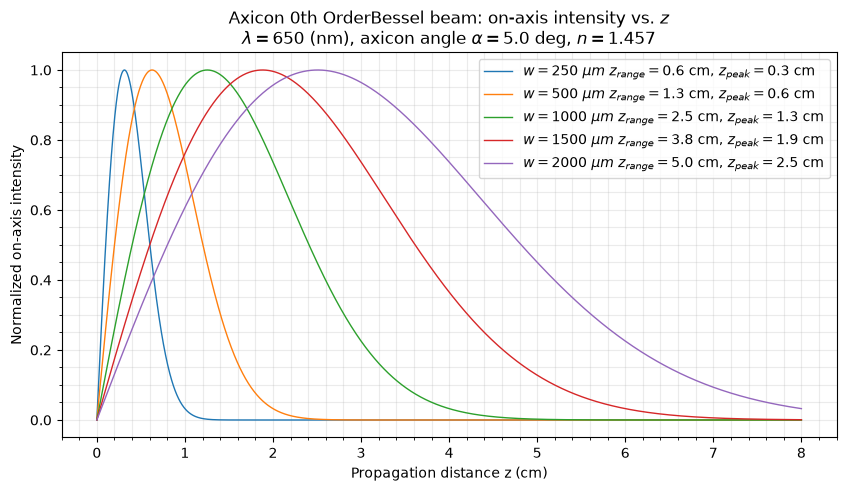

In [15]:
# plot on-axis intensity vs. z for different beam waists
params = AxiconParams(
    wavelength_nm=650,
    n=1.457,
    alpha_deg=5.0,
)
params.check_small_angle_approximation()
# 0th Bessel order
ell = 0

# Beam waists at the axicon
w_um_values = [250, 500, 1000, 1500, 2000]
z_m = np.linspace(0, 0.08, 2000)  # 0 to 8 cm
fig, ax = plt.subplots(figsize=(10, 5))
plt.minorticks_on()

for w_um in w_um_values:
    I_axis = bessel_gauss_intensity(
        r_m=0,
        z_m=z_m,
        w_um=w_um,
        params=params,
        ell=ell,
        normalize_peak=True,
    )

    zmax = zmax_axicon(w_um, params)
    zpeak = zmax / 2  # for ell = 0

    ax.plot(z_m * 100, I_axis, label=rf"$w={w_um}\ \mu m$ $z_{{range}}={zmax*100:.1f}$ cm, $z_{{peak}}={zpeak*100:.1f}$ cm", linewidth=1)



ax.set_xlabel("Propagation distance z (cm)")
ax.set_ylabel("Normalized on-axis intensity")
ax.set_title(r"Axicon 0th OrderBessel beam: on-axis intensity vs. $z$" 
             + "\n" + rf"$\lambda={params.wavelength_nm}$ (nm), axicon angle $\alpha={params.alpha_deg}$ deg, $n={params.n}$")
ax.grid(alpha=0.25, visible=True, which='both')

ax.legend()
plt.show()

k = 5.905e+06 1/m
k_r = 5.153e+04 1/m
k_r small-angle approx = 5.153e+04 1/m
relative error = 1.269e-05


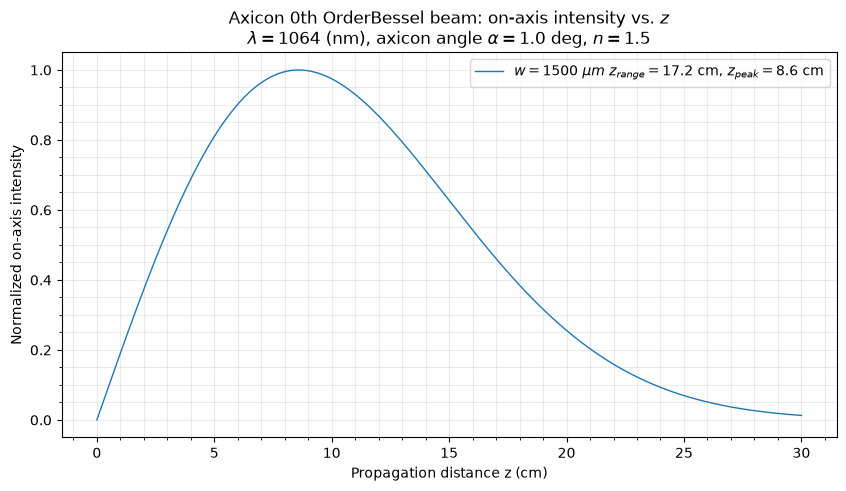

In [16]:
# sanity check: Rao pg 15 gives z_max = 17.2cm and z(I_max) = 8.6cm for 1064nm beam with w=1.5mm
# our results should match table 1 (but we only care about the 0th order Bessel beam, ell=0)
params = AxiconParams(
    wavelength_nm=1064,
    n=1.5,
    alpha_deg=1.0
)
params.check_small_angle_approximation()
# 0th Bessel order
ell = 0

# Beam waists at the axicon
w_um =1500
z_m = np.linspace(0, 0.30, 2000)  # 0 to 20 cm
fig, ax = plt.subplots(figsize=(10, 5))
plt.minorticks_on()

I_axis = bessel_gauss_intensity(
        r_m=0,
        z_m=z_m,
        w_um=w_um,
        params=params,
        ell=ell,
        normalize_peak=True,
    )

zmax = zmax_axicon(w_um, params)
zpeak = zmax / 2  # for ell = 0

ax.plot(z_m * 100, I_axis, label=rf"$w={w_um}\ \mu m$ $z_{{range}}={zmax*100:.1f}$ cm, $z_{{peak}}={zpeak*100:.1f}$ cm", linewidth=1)



ax.set_xlabel("Propagation distance z (cm)")
ax.set_ylabel("Normalized on-axis intensity")
ax.set_title(r"Axicon 0th OrderBessel beam: on-axis intensity vs. $z$" 
             + "\n" + rf"$\lambda={params.wavelength_nm}$ (nm), axicon angle $\alpha={params.alpha_deg}$ deg, $n={params.n}$")
ax.grid(alpha=0.25, visible=True, which='both')

ax.legend()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import jv
from matplotlib.colors import PowerNorm

params = AxiconParams(
    wavelength_nm=650,
    n=1.457,
    alpha_deg=5.0,
)
params.check_small_angle_approximation()
# 0th Bessel order
ell = 0

def make_xz_intensity_map(w_um, ell=0):
    zmax = zmax_axicon(w_um, params)

    # Use signed transverse coordinate x instead of one-sided radial coordinate r
    x_m = np.linspace(-0.1e-3, 0.1e-3, 900)  # -0.35 mm to +0.35 mm
    z_m = np.linspace(0, zmax, 900)

    X, Z = np.meshgrid(x_m, z_m)
    R = np.abs(X)

    I_map = bessel_gauss_intensity(
        r_m=R,
        z_m=Z,
        w_um=w_um,
        params=params,
        ell=ell,
        normalize_peak=True,
    )

    fig, ax = plt.subplots(figsize=(10, 5))

    im = ax.imshow(
        I_map,
        extent=[x_m.min()*1e3, x_m.max()*1e3, z_m.min()*100, z_m.max()*100],
        origin="lower",
        aspect="auto",
        norm=PowerNorm(gamma=0.45, vmin=0, vmax=1),
    )

    ax.set_xlabel("Transverse position x (mm)")
    ax.set_ylabel("Propagation distance z (cm)")
    ax.set_title(rf"Axicon-generated Bessel beam x-z intensity map, $w={w_um}\ \mu m$" + 
                "\n" + rf"$\lambda={params.wavelength_nm}$ (nm), axicon angle $\alpha={params.alpha_deg}$ deg, $n={params.n}$")

    fig.colorbar(im, ax=ax, label="Normalized intensity")
    plt.show()

make_xz_intensity_map(w_um=1500)

k = 9.666e+06 1/m
k_r = 3.854e+05 1/m
k_r small-angle approx = 3.855e+05 1/m
relative error = 2.651e-04


TypeError: zmax_axicon() missing 1 required positional argument: 'params'

In [ ]:
# sanity check: plotting the radial Bessel profile should not change for different beam waists, if we plot position normalized as z/zmax
# in othher words, the radial profile is the same at a given fraction of zmax, regardless of the beam waist
# for w_um in w_um_values:
    # make_xz_intensity_map(w_um=w_um)
    # make_normalized_r_vs_z_intensity_plot(w_um=w_um)